In [24]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

Files were obtained via NASA HEASARC mirror. The data files are compressed FITS files and will therefore be read with Astropy.

In [ ]:
# open file and showcase basic info
hdul = fits.open('../data/P0953011701PNU002SRSPEC0001.FTZ')
hdul.info()

Filename: ../data/P0953011701PNU002SRSPEC0001.FTZ
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     135   ()      
  1  SPECTRUM      1 BinTableHDU     80   4096R x 4C   [I, J, I, I]   
  2  REGION        1 BinTableHDU     23   1R x 4C   [16A, E, E, E]   
  3  GTI00005      1 BinTableHDU     22   12R x 2C   [D, D]   


The code below and its output proves that the data I am using for my project is from XMM-Newton's EPIC-pn instrument. 
It also helps me become more familiar with the structure of data.

In [ ]:
# plotting basic information of the file
hdr = hdul[0].header
print(hdr["TELESCOP"], hdr["INSTRUME"], hdr["DATE-OBS"])

hdr = hdul[1].header
print(hdr["HDUCLASS"], hdr["HDUCLAS1"], hdr["HDUCLAS2"], hdr["POISSERR"])

# retrieve data and print columns for later use
data = hdul["SPECTRUM"].data
print(data.columns)


XMM EPN 2024-09-22T10:23:34
OGIP SPECTRUM TOTAL True
ColDefs(
    name = 'CHANNEL'; format = 'I'
    name = 'COUNTS'; format = 'J'; unit = 'count'
    name = 'GROUPING'; format = 'I'
    name = 'QUALITY'; format = 'I'
)


Below is a plot of supposedly the raw spectrum data.

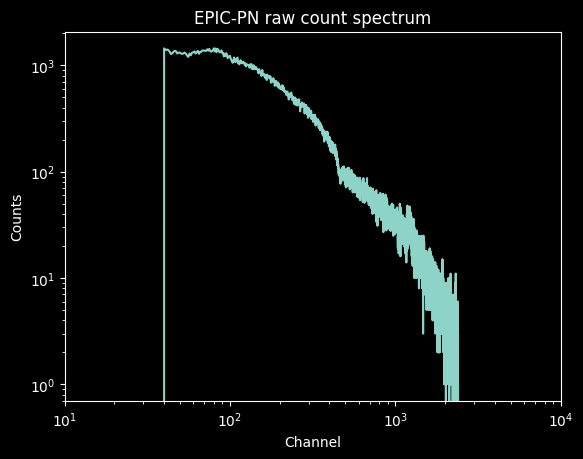

In [ ]:
channels = data["CHANNEL"]
counts = data["COUNTS"]

# plotting channel-count
plt.plot(channels, counts)
plt.yscale('log')
plt.xscale('log')
plt.xlim(10,10000)
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.title('EPIC-PN raw count spectrum')
plt.show()

There is an unnatural jump at the beginning of the spectrum. This is most likely due to the energy range of the detector. As for the decline towards the end of the spectrum, this is most likely due to the properties of the AGN itself. There seems to be a smooth curve down, indicating a continuum source, which is to be expected from Mrk279. One could also expect a form of power-law emission which does seem to be present with a break at a channel value of around 30. Furthermore, the end of the spectrum also demonstrates the Poisson error on the data quite well. As higher energy counts become scarcer, the statistical uncertainty becomes much more visible. This could also be because of the effective area of the detector decreasing.

I will not convert the channel quantity to energy using the RMF EBOUNDS table. First I want to know what the supposed energy range that is that is being plotted by checking PI. 

In [38]:
PI_read = hdul["SPECTRUM"].header

# optional print that showcases all data stored in the header with comments.
# for key in PI_read:
#     comment = PI_read.comments[key]
    
#     print(f"{key:10} | {comment}")

# print key data required to convert the counts-channel plot to counts-energy.
for key in hdr:
    if "CHANTYPE" in key or "DETCHANS" in key or "SPECDELT" in key or "TL" in key or "RESPFILE" in key or "E_MIN" in key or "BACKSCAL" in key or "ANCRFILE" in key or "FILTER" in key:
        print(key, ":", PI_read[key])

FILTER : Medium
CHANTYPE : PI
DETCHANS : 4096
SPECDELT : 5
BACKSCAL : 1979780
ANCRFILE : P0953011701PNU002SRCARF0001.FTZ
RESPFILE : epn_e3_sw20_sdY9.rmf
TLMIN1 : 0
TLMAX1 : 4095


I will now interpret parts of the output above. Let's start with the filter: medium. This means the observation used the medium optical blocking filter, meaning that optical and UV bands are moderately surpressed to prevent contamination. This would be represent by a lower count value in this region. 

Chantype: PI means the spectrum is binned in Pulse Invariant channels. It means the channels are energy calibrated which is beneficial as converting channel values to energy will be easier. 

Detchans: 4096, TLMIN1: 0, TLMAX1: 4095 means that there are a total of 4096 detector channels labelled from 0 to 4095. 

Specdelt: 5 means that each PI channel corresponds to 5 eV. This would mean that the entire PI channel range is 4096 * 5 = 20.48 keV.

BACKSCAL: 1979780 represents the geometric scaling factor. It is proportional to the number of active detector pixels in extraction region. It is used to properly scale background subtraction.

ANCRFILE: P0953011701PNU002SRCARF0001.FTZ contains data about the effective area vs energy, filter transmission among others. It accounts for detector efficiency and extraction-region corrections.

RESPFILE: epn_e3_sw20_sdY9.rmf is the calibration redistribution matrix. It maps photon energy to PI channels.

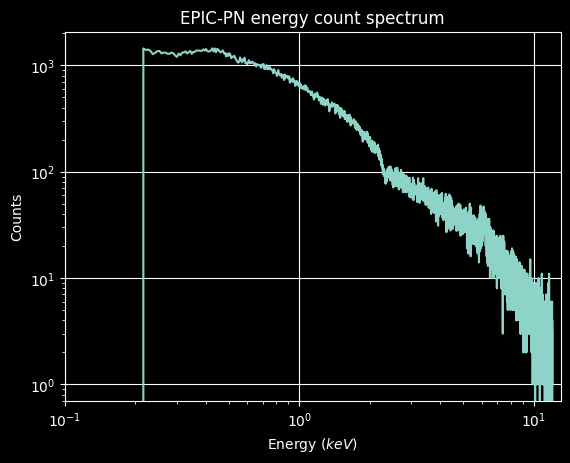

In [ ]:
# open the rmf
rmf = fits.open("../data/P0953011701PNU002SP4RMF0001.FTZ")
# 2 because that is where ebounds is stored according to rmf.info()
rmf_hdr = rmf[2].header

# retrieve data and energy min and max bound
rmf_data = rmf[2].data 
emin = rmf_data["E_MIN"]
emax = rmf_data["E_MAX"]

# calculate central energy value from ebounds
energy = (emin + emax) * 0.5

# plot new spectrum
plt.plot(energy, counts)
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.1, 13)
plt.xlabel('Energy $(keV)$')
plt.ylabel('Counts')
plt.title('EPIC-PN energy-count spectrum')
plt.grid(True)
plt.show()

This spectrum demonstrates similar characteristics to the channel-count spectrum. The most interesting things to note is that there is a soft excess present until roughly 1 keV, after which there is a break, presumably a power law that should be present according to previous literature concering Mrk279. There seems to be a spectral line at 6 keV, which matches the iron k&alpha; line.

to avoid memory leaks, close the data file

In [ ]:
hdul.close()
rmf.close()